In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/AusApparalSales4thQrt2020.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


In [11]:
import pandas as pd

data={'Group': ['Kids','Men','Women','Senior','Kids']}

df = pd.DataFrame(data)
print(df)

df.groupby(['Group'], sort = False).sum()

    Group
0    Kids
1     Men
2   Women
3  Senior
4    Kids


""
Group
Kids
Men
Women
Senior


In [ ]:
df.shape

(7560, 6)

In [ ]:
df.drop(['Date', 'Time', 'State'], axis = 1, inplace = True)

In [ ]:
column=df.columns

In [ ]:
df.drop(column[0], axis = 1, inplace = True)

In [ ]:
df.head(2)

,Unit,Sales
0,8,20000
1,8,20000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Unit    7560 non-null   int64
 1   Sales   7560 non-null   int64
dtypes: int64(2)
memory usage: 118.3 KB


In [ ]:
df.isnull().sum()

,0
Unit,0
Sales,0


In [ ]:
len(df)


7560

In [ ]:
df.duplicated().sum()

np.int64(7496)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

(64, 2)

In [ ]:
df.head(2)

,Unit,Sales
0,8,20000
2,4,10000


<Axes: xlabel='Unit', ylabel='count'>

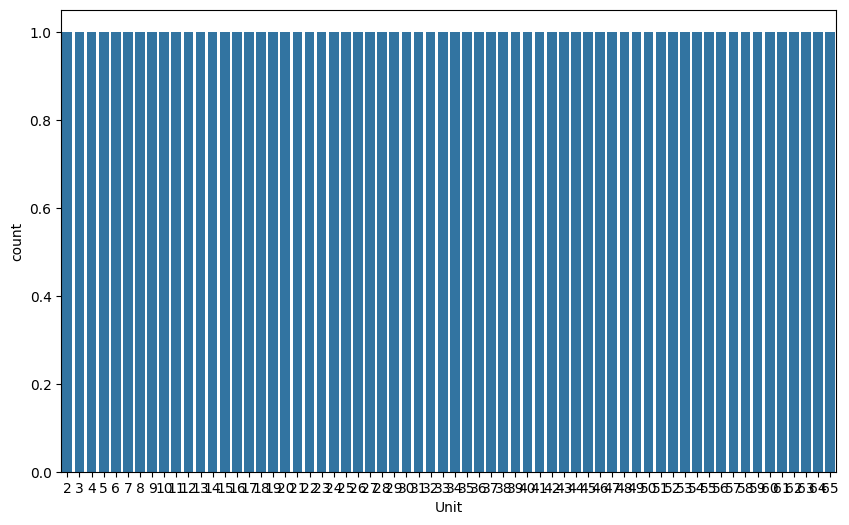

In [ ]:
plt.figure(figsize = (10,6))
sns.countplot(data = df, x = 'Unit')

<Axes: >

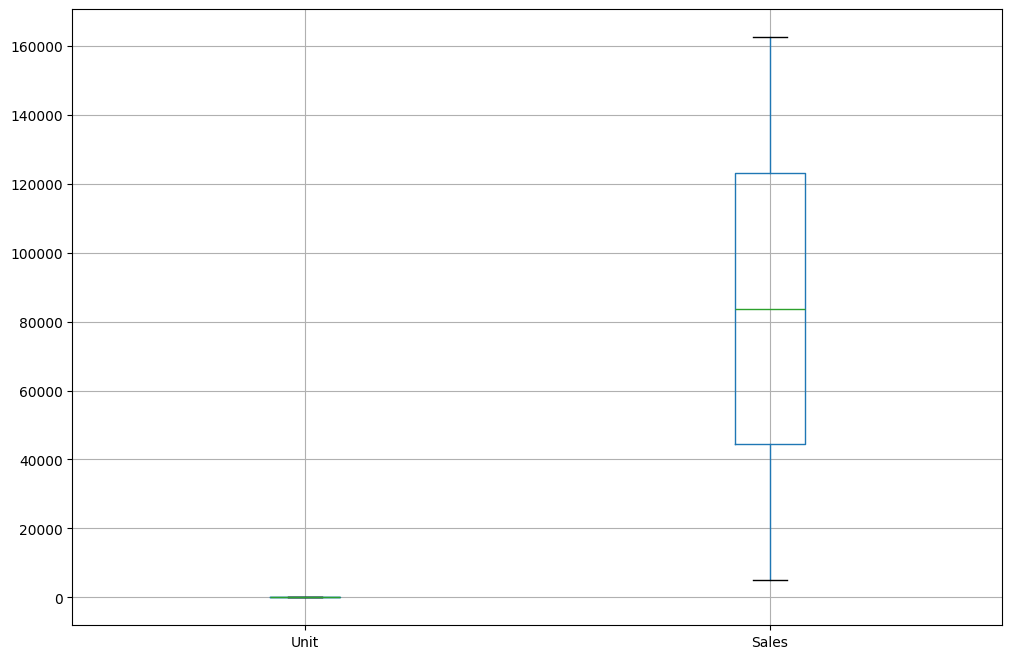

In [ ]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Create box plots for each numerical column
plt.figure(figsize=(12, 8))
df[numerical_columns].boxplot()

<Axes: xlabel='Unit', ylabel='Sales'>

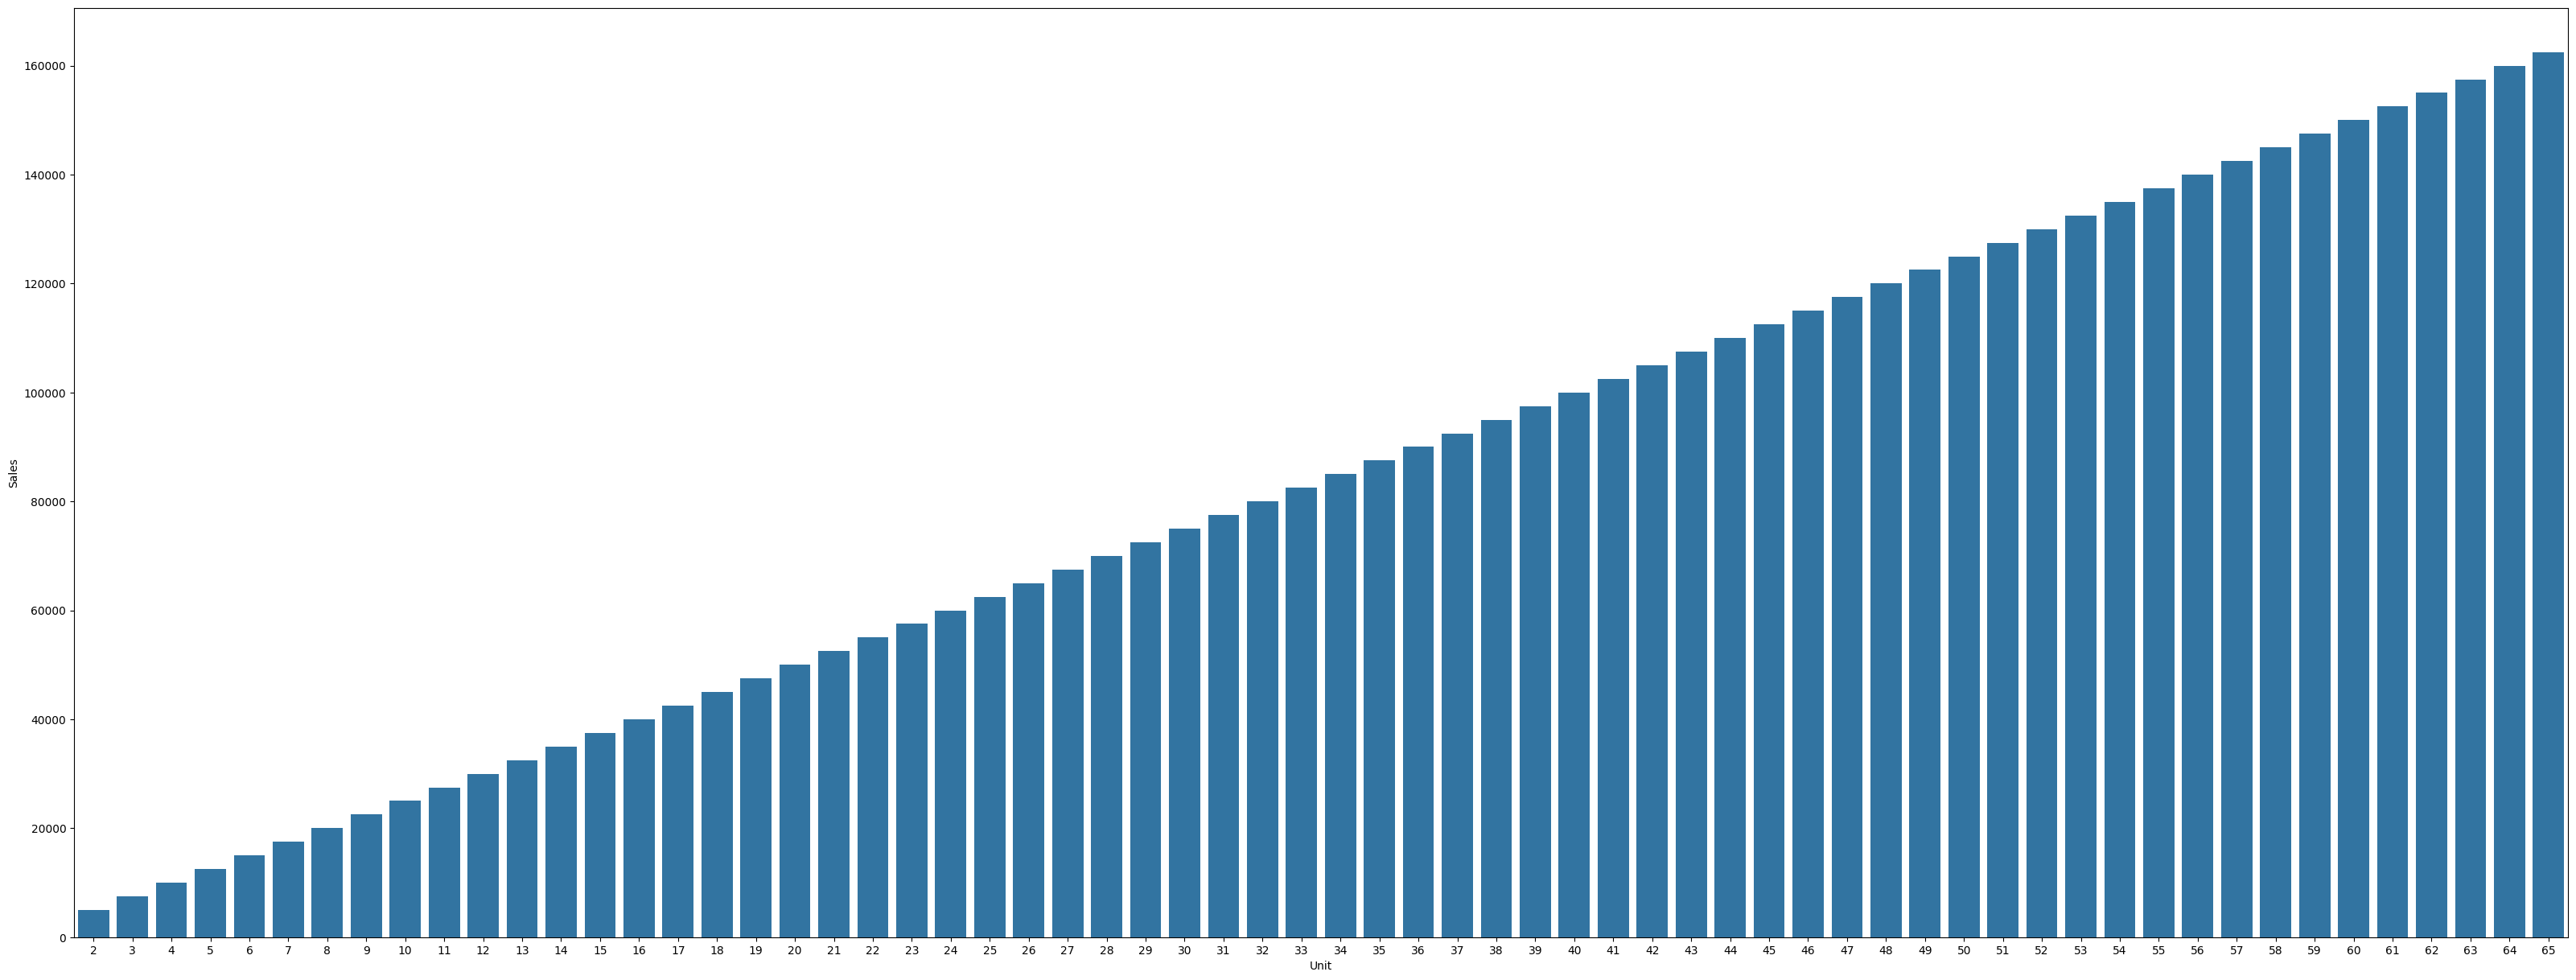

In [ ]:
plt.figure(figsize = (40,15))
sns.barplot(data = df, x = 'Unit', y = 'Sales')

<Axes: >

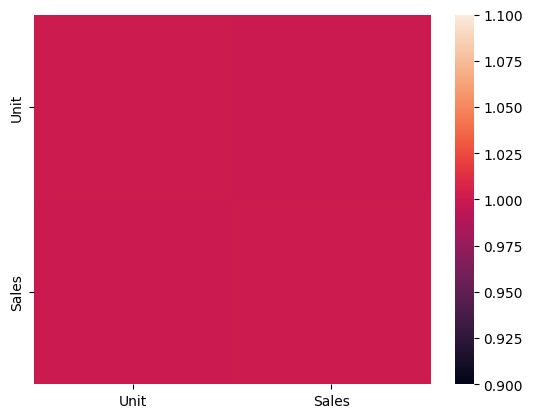

In [ ]:
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix)

In [ ]:
df['Sales'].value_counts()

,count
Sales,
20000,1
10000,1
37500,1
7500,1
25000,1
...,...
150000,1
137500,1
162500,1


In [ ]:
df_encoded = pd.get_dummies(df, columns = ['Sales'], drop_first = True)

In [ ]:
df_encoded.head(2)

,Unit,Sales_7500,Sales_10000,Sales_12500,Sales_15000,Sales_17500,Sales_20000,Sales_22500,Sales_25000,Sales_27500,...,Sales_140000,Sales_142500,Sales_145000,Sales_147500,Sales_150000,Sales_152500,Sales_155000,Sales_157500,Sales_160000,Sales_162500
0,8,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,4,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df['Sales'].value_counts()

,count
Sales,
20000,1
10000,1
37500,1
7500,1
25000,1
...,...
150000,1
137500,1
162500,1


In [ ]:
df = pd.get_dummies(df_encoded, columns = ['Unit'], drop_first = True)

In [ ]:
df.head(2)

,Sales_7500,Sales_10000,Sales_12500,Sales_15000,Sales_17500,Sales_20000,Sales_22500,Sales_25000,Sales_27500,Sales_30000,...,Unit_56,Unit_57,Unit_58,Unit_59,Unit_60,Unit_61,Unit_62,Unit_63,Unit_64,Unit_65
0,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
